# Project 1: Numerov's method

In this project you will use Numerov's method to solve the stationary Schrödinger equation numerically. Numerov's method solves second-order ODEs of the form

\begin{equation}
  \frac{d^2 y}{dx^2} = f(x) + g(x)\, y(x)
\end{equation}

Because there is no first-derivative term and $y(x)$ only enters linearly on the right-hand side, one can build a very simple, very accurate (fifth-order) method out of this equation, see the lecture slides for the derivation. Discretizing the $x$ axis into points $\{x_0, x_1, \dots\}$ and writing $y_n = y(x_n)$, $f_n = f(x_n)$, $g_n = g(x_n)$, Numerov's method propagates the solution with the recursion

\begin{equation}
  y_{n+1} = \frac{2y_n - y_{n-1} + \frac{h^2}{12} \Big(f_{n+1} + 10 \,
  (f_n + g_n y_n) + f_{n-1} + g_{n-1}y_{n-1}\Big)}{1 - \frac{g_{n+1} h^2}{12}} + O(h^6)
\end{equation}

The same recursion also works backwards, propagating from $x_N$ down to $x_0$ (this will be useful in Part 3).


In [1]:
# Common imports
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Callable

## Part 1: Implement Numerov's method

Write a function with the following signature:

```python
def numerov(
    x: np.ndarray,
    y: np.ndarray,
    f: Callable[[float], float],
    g: Callable[[float], float],
    y0: float,
    y1: float,
) -> None:
    ...
```

`x` is a `numpy.ndarray` containing the discretized $x$ points, and `y` is a `numpy.ndarray`, originally empty, that the function fills in place with the solution. `f` and `g` are the two functions defined above, and `y0`, `y1` are the first two values needed to start the recursion (in Python there is no trouble passing a function as an argument to another function).

Test your implementation on the simple case $f(x)=0$, $g(x)=-1$, whose general solution is

\begin{equation}
  y(x) = A \cos( x + \phi )
\end{equation}

You can check a specific solution by choosing

\begin{equation}
  y_0 = A \cos( x_0 + \phi ) \qquad y_1 = A \cos ( x_0 + h + \phi )
\end{equation}

where $x_0$ is the first discretized point and $h$ the step size. Then investigate how sensitive the result is to the choice of $h$: does the error shrink the way you would expect from a fifth-order method?


In [2]:
def numerov(fun_f, fun_g, x0, xfinal, y0, y1, N=50):
    # fun_f: f(x) function that receives x:float -> float 
    # fun_g: g(x) function that receives x:float -> float
    # x_0: lower limit on the x axis
    # x_final: upper limit on the x axis
    # y0, y1: initial y values that have to be known
    # N: number of steps that we require


    x = np.linspace(x0, xfinal, N+1) 

    y = [y0, y1]

    n = 1

    if N <= n:
        raise ValueError("The number of steps should be bigger than 1.") 

    while n < N: 

        y_nplus1 = ( 2*y[n] - y[n-1] + (h**2 / 12)*(fun_f(x[n+1]) + 10*(fun_f(x[n]) + fun_g(x[n])*y[n]) + fun_f(x[n-1]) + fun_g(x[n-1])*y[n-1]) )
        y_nplus1 = y_nplus1 / (1 - (fun_g(x[n+1])*(h**2))/12)
        y.append(y_nplus1) 

        n = n + 1


    return x, y




In [7]:
# Lets check the algorithm.

def fun_f(x):
    f = 0

    return f

def fun_g(x):
    g = -1

    return g

def fun_y(x,A=1,phi=0):
    # x
    # A: amplitude of the cosine, by defect is equal to 1
    # phi: phase of the cosine, by defect is equal to zero 

    y = A * np.cos(x + phi)

    return y

# ----------------------------------------

x0 = 0
xfinal = 2*np.pi
N = 100
h = (xfinal-x0)/N
y0 = fun_y(x0)
y1 = fun_y(x0+h)



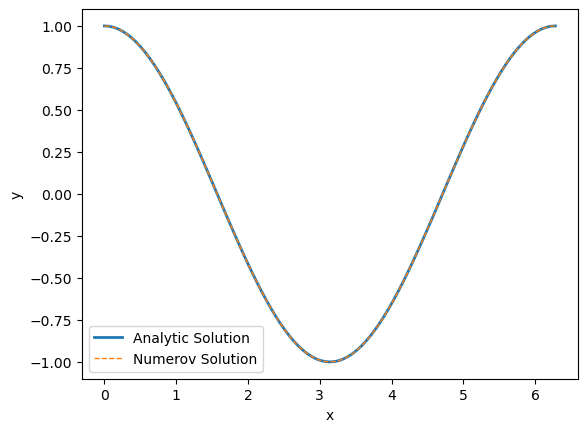

In [8]:
# Plotting of real values of y = cos(x) versus numerov results. 

y_real = [fun_y(x0)]
x, y_numerov = numerov(fun_f=fun_f, fun_g=fun_g, x0=x0, xfinal=xfinal, y0=y0, y1=y1, N=N)

for i in range (1,N+1, 1):
    y_real.append(fun_y(x0 + i*h))

plt.plot(x, y_real, label='Analytic Solution', linewidth=2)
plt.plot(x, y_numerov, '--', label='Numerov Solution', linewidth=1)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()



## Part 2: Finding bound states (the shooting method)

In the following parts, we will be interested in solving the stationary Schrödinger
equation

\begin{equation}
  -\frac{\hbar^2}{2m} \frac{d^2 \psi}{dx^2} + V(x) \psi(x) = E \psi(x)
\end{equation}

which is the same as the Numerov general equation above with

\begin{equation}
  f(x) = 0 \qquad g(x) = \frac{2m}{\hbar^2} \Big( V(x) - E \Big)
\end{equation}

It is convenient to work in units where $\hbar=1$ and $m=1$.

Let us first consider the infinite potential well, i.e. a potential
$V(x) = 0$ in the interval $[0,a]$ and $V(x) = \infty$ everywhere else.
As you remember from your quantum mechanics course, the solutions
to this problem can be chosen to be real and yield an infinite
countable number of bound states with well-defined energies:

\begin{equation}
  E_n = \frac{n^2 \hbar^2 \pi^2}{2 m a^2}
\end{equation}

How can you solve this problem numerically? It is clear that we know
the boundary conditions:

\begin{equation}
  \psi(0) = \psi(a) = 0
\end{equation}

We can use Numerov's method and solve for $\psi(x)$ starting
from $x=0$ with $\psi_0 = \psi(0) = 0$. We can then actually
choose $\psi_1 = \psi(h)$ freely because the wavefunction
that is solution to the Schrödinger equation is only defined up to a
multiplicative factor. For a randomly chosen energy $E$ what will
happen is that the solution found using Numerov's method will have
a finite value $m = \psi(a)$ at $x=a$. But we know the wavefunction
should vanish there.

In order to find the wavefunctions that satisfy the boundary
conditions you can use the **shooting method**: start from some
energy $E$ and change it until you find that the mismatch
$m$ is zero.

You can proceed in the following steps:

1. Write a function of the energy (and other relevant parameters)
   ```python
   def get_mismatch(energy, ...)
   ```
   that returns the value of the mismatch at $x=a$

2. Make a plot of this mismatch as a function of energy. What do you
   observe?

3. Find the energies for which the mismatch is zero. Basically, you
   just have to find the zeros of the `get_mismatch` function. There
   are many tools to do this. Try to find one from the
   [scipy project](http://docs.scipy.org/doc/scipy/reference).
   *Hint*: What about [`scipy.optimize.brentq`](http://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.brentq.html#scipy.optimize.brentq)?

4. Plot the wavefunction for the eigenenergies you found and see
   whether they behave like you expect (number of nodes, etc.).

5. It might be nicer to wrap the methods you have used into a
   class. Try to see if you know how this could be done.


In [24]:
def V(x,x_low,x_up):
    if x >= x_low and x <= x_up:
        V = 0
    else:
        V = float('inf')

    return V


def get_mismatch(E,V,x0,xfinal,y0,y1,N=50):

    def fun_f(x):
        f = 0
        return f


    def fun_g(x):
        g = 2*(V(x,x0,xfinal)-E)
        return g

    x,y_num = numerov(fun_f,fun_g,x0,xfinal,y0,y1,N)
    a = x[-1]
    mismatch = y_num[-1] #mismatch = y(a)

    return mismatch

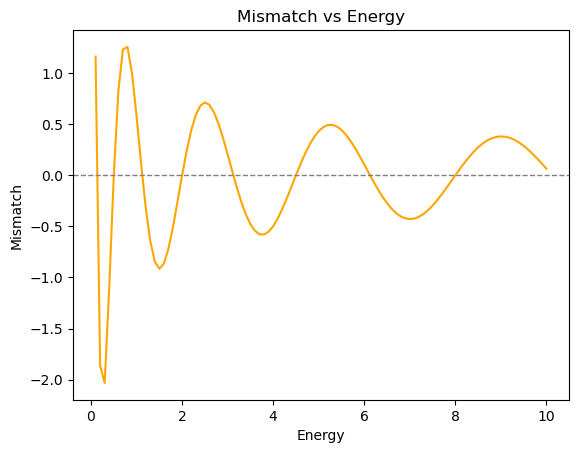

In [39]:
E_min = 0.1
E_max = 10
E_array = np.linspace(E_min,E_max,100)

x0_p2=0
y0_p2=0
N_p2=100
xfinal_p2=10
y1_p2= 0.1 #random number

mismatch_array = [get_mismatch(E, V, x0_p2, xfinal_p2, y0_p2, y1_p2, N_p2) for E in E_array]

plt.plot(E_array, mismatch_array, color='orange')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)  # línea de referencia en y=0
plt.xlabel('Energy')
plt.ylabel('Mismatch')
plt.title('Mismatch vs Energy')
plt.show()


In [40]:
from scipy import optimize

roots = []

for i in range(len(E_array) - 1):
    if mismatch_array[i] * mismatch_array[i+1] < 0:   # cambio de signo
        raiz = optimize.brentq(get_mismatch, E_array[i], E_array[i+1],
                       args=(V, x0_p2, xfinal_p2, y0_p2, y1_p2, N_p2))
        roots.append(raiz)

print("Found energies:", roots)


Found energies: [0.12499999949264966, 0.49999996752521564, 1.1249996300196123, 1.9999979206386238, 3.1249920650796152, 4.499976296299862, 6.124940197915333, 7.999866672241618]


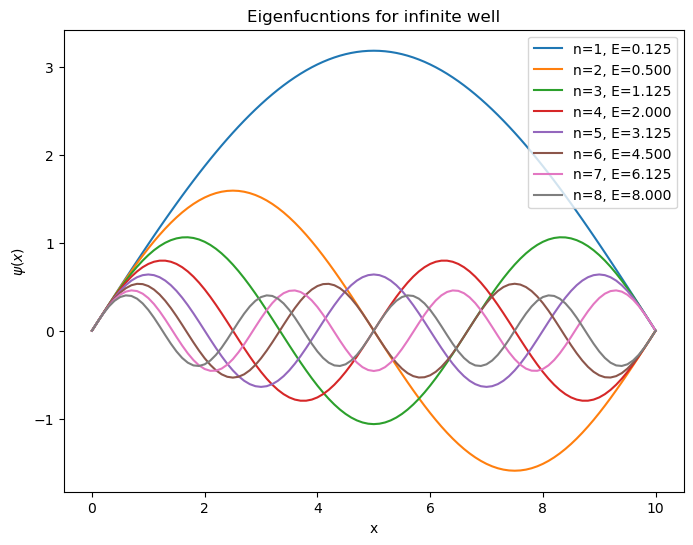

In [41]:
plt.figure(figsize=(8,6))

for n, E in enumerate(roots, start=1):
    def fun_f(x):
        return 0

    def fun_g(x):
        return 2*(V(x, x0, xfinal) - E)

    x_vals, psi = numerov(fun_f, fun_g, x0_p2, xfinal_p2, y0_p2, y1_p2, N_p2)
    plt.plot(x_vals, psi, label=f'n={n}, E={E:.3f}')

plt.xlabel('x')
plt.ylabel(r'$\psi(x)$')
plt.legend()
plt.title('Eigenfucntions for infinite well')
plt.show()


## Part 3: Bound states with asymptotic boundary conditions

In the infinite potential well problem, the boundary conditions are very easy. It is enough
to ask that the wavefunction be zero at the edges of the well. However, in most cases one
is not dealing with a truly infinite potential. In the case of bound states in a generic
potential, one will usually have two side regions where the wavefunction goes to zero
as $|x| \rightarrow \infty$ and a central region with an oscillatory behavior. In that
more generic case, the boundary conditions are given at infinity (where the wavefunction
is going to zero). This is illustrated in the
plot below, where we show a potential $V(x)$ and one of the eigenstates that decays to zero as
$|x| \rightarrow \infty$:

![Example of bound state](boundstate.png)

The dashed line is the energy of the bound state. It crosses the potential $V(x)$
at the values $x_L$ and $x_R$. We can expect the wavefunction to have an oscillatory behavior
between $x_L$ and $x_R$ and to decay exponentially to zero for $x < x_L$ and
$x > x_R$.

Dealing with a condition at infinity is not very difficult. It is enough to work in a
large window $[x_\mathrm{min}, x_\mathrm{max}]$ and ask for the wavefunction to be zero
at $x_\mathrm{min}$ and $x_\mathrm{max}$. One can then increase the size of the window
to see if results change or not.

The problem is how to satisfy the boundary conditions. One could in principle use the
shooting method again: start from the left with a wavefunction that is zero at $x_\mathrm{min}$
and then propagate using Numerov's method all the way to $x_\mathrm{max}$ and tune the energy
until the wavefunction is zero at $x_\mathrm{max}$.

There is however a problem with this approach. Propagating the wavefunction from the oscillatory
region into the exponentially decaying region will lead to a large error accumulation. This is
because an exponentially increasing solution is also a possible solution of the equation and
can destroy the accuracy of the algorithm. The rule of thumb is to
avoid integrating into the exponential regions.

Instead, it is more efficient to propagate both forward from the left and backward from
the right and impose that both solutions satisfy the continuity conditions at a point
$x_0$ somewhere in the oscillatory region. In practice you can follow these steps
in your code:

1. Choose a large window (large enough that you expect the wavefunction to be
   essentially zero at the boundaries) $[x_\mathrm{min}, x_\mathrm{max}]$.

2. Integrate the solution first starting from $x_\mathrm{min}$ up to a given value $x = x_0$
within the interval $x_L \le x_0 \le x_R$. One can typically choose $x_0 = x_R$. We will
call this solution $\psi_L(x)$.

3. Integrate the solution starting from $x_\mathrm{max}$ down to $x = x_0$. We will call this
solution $\psi_R(x)$. You will need to write a modified version of the `numerov` function
that integrates the solution backward.

4. With the correct energy, the following continuity conditions should be
   satisfied at $x = x_0$, i.e.:

   \begin{align}
       \psi_R(x_0) &= \psi_L(x_0) \\
       \psi'_R(x_0) &= \psi'_L(x_0)
   \end{align}

   Both $\psi_R$ and $\psi_L$ are solutions up to a multiplicative factor. So one can always
   normalize them to be equal at $x_0$. The conditions above can then be rewritten as a
   single matching condition for the logarithmic derivative:

   \begin{equation}
       \frac{\psi'_R(x_0)}{\psi_R(x_0)} = \frac{\psi'_L(x_0)}{\psi_L(x_0)}
   \end{equation}

   Define a function of the energy (and other relevant parameters)
   ```python
   def get_mismatch(energy, ...)
   ```
   that returns the value of the logarithmic derivative mismatch at $x=x_0$.

5. Make a plot of this mismatch as a function of energy. What do you
   observe?

6. Find the energies for which the mismatch is zero.

7. Plot the wavefunctions for the eigenenergies you found and see
   whether they behave like you expect (number of nodes, etc.).

8. Again, it might be nicer to wrap the methods you have used into a
   class. Try to see if you know how this could be done.

9. Test your code for the following potential:

   \begin{equation}
      V(x) = \frac{\hbar^2}{2m} \alpha^2 \lambda (\lambda-1) \Big[ \frac{1}{2} - \frac{1}{\cosh^2 (\alpha x)} \Big]
   \end{equation}

   You can consider the case $\alpha = 1$ and $\lambda = 4$ and take units such that $\hbar = m = 1$.


In [ ]:
def numerov_backward(fun_f,fun_g,x0,xfinal,y0,y1,N=50):
    x_rev, y_rev = numerov(fun_f,fun_g,xfinal,x0,y0,y1,N) #x0 and xfinal get inversed 
    return x_rev[::-1], y_rev[::-1]

xl,xr = 0,10
x0 = 5
xmin = -10000
xmax = 10000

def V_p3(x,alpha,lam):
    return 0.5*(alpha**2)*lam*(lam-1)*(0.5 - (1/ (np.cosh(x*alpha))**2))

def fun_f(x):
    f = 0
    return f

def fun_g(x,alpha,lam):
    g = 2*(V(x,alpha,lam)-E)
    return g




## Part 4: Quantum scattering

Congratulations if you made it here! This last part is not compulsory, I have put it here
for completeness. You can try to solve it if you have time.

Here, we want to focus on scattering states, namely states that have an energy higher than
the asymptotic value of the potential. They are quite different from the bound states
we studied above for two reasons. First, there is no quantization of the energy, we will
not have to find eigenenergies. Second, the wavefunction is a complex function. It cannot
always be made real like for bound states.

We will suppose that the potential is zero except in some central region $[x_\mathrm{min}, x_\mathrm{max}]$.
Here is an example of such a potential:

![Scattering potential](scattering.png)

The black line is the potential and the blue and orange curves are the real and imaginary part
of a given scattering state (here with energy $E=0.7$).
We know the expression for the wavefunction on the left $\psi_L(x)$ and on the right $\psi_R(x)$
is given by

\begin{equation}
  \psi_L(x) = e^{ikx} + A e^{-ikx} \qquad \psi_R(x) = B e^{ikx}
\end{equation}

If the energy is given by $E$, then we have

\begin{equation}
  k^2 = \frac{2 m E}{\hbar^2}
\end{equation}

Note that we explicitly assumed that the scattering state travels from the left to
the right (there is no wave coming back from the right). We also chose to normalize
the wavefunction such that the first prefactor of $\psi_L$ is 1.

Given the energy $E$ we need to find the complex coefficients $A$ and $B$. This can
be done following these steps:

1. Start with a guess $A_r$ for $A$.
2. Propagate the solution from $x_\mathrm{min}$ to $x_\mathrm{max}$. You can
   find the initial conditions analytically. Let's call $\psi_{0r}$ the value of the
   wavefunction at $x_\mathrm{min}$.
3. From the obtained solution at $x_\mathrm{max}$, deduce the value of $B$.
4. With this value of $B$ and your knowledge of $\psi_R(x_\mathrm{max})$
   and $\psi'_R(x_\mathrm{max})$ propagate the solution back to
   $x_\mathrm{min}$.
5. This solution at $x_\mathrm{min}$ has a value $\psi_{0l}$.
6. Of course, the correct $A$ is such that $\psi_{0r} = \psi_{0l}$. So you can define
   a mismatch function

   ```python
   def get_mismatch(a_coef)
   ```

   that returns $|\psi_{0r}-\psi_{0l}|^2$. Here `a_coef` is a tuple `[A_r_real, A_r_imag]`
   made of the real and imaginary part of $A_r$. Instead of finding the zero
   of `get_mismatch`, you can try to use a minimization function. Finding a minimum
   for a function of several variables is often more efficient. You can use
   the function `scipy.optimize.minimize`. Of course one should check that the minimum
   value that is found is indeed 0.
7. You can then check your code for the potential depicted above, namely the function

   \begin{equation}
     V(x) = 1 \quad \text{if} \quad 0 < x < 1 \quad \text{or} \quad 3 < x < 5
     \quad \text{otherwise} \quad V(x) = 0
   \end{equation}
8. Plot the wavefunction for a chosen energy, e.g. $E = 0.7$.
9. Plot the logarithm of the transmission $T = 1-|A|^2$ for energies in the
   interval $[0,2]$. What do you observe at $E \simeq 0.4$?
10. You might have noticed that the code does take some time to run. How could it be
    optimized?
